# DETECCIÓN DE PEATONES CON HOG Y SVM — INRIA Person Dataset
### Dataset: INRIA Person Dataset (Dalal & Triggs, 2005)
### ftp://ftp.inrialpes.fr/pub/lear/douze/data/INRIAPerson.tar

**Basado en el notebook de detección de vehículos del Dr. David Antonio-Torres.** 

---
### Diferencias clave respecto al notebook de vehículos
| Aspecto | Vehículos (original) | INRIA (este notebook) |
|---|---|---|
| Imágenes | Pre-recortadas 64×64 PNG | Imágenes completas + anotaciones texto |
| Carga | `glob` directo | Parsing de anotaciones INRIA + extracción de crops |
| Clase negativa | Fondo sin vehículo (pre-recortado) | Parches aleatorios de imágenes de fondo |
| HOG cells | 16×16 px | **8×8 px** (estándar Dalal & Triggs) |
| Orientaciones | 11 | **9** (estándar HOG) |
| Tamaño imagen | 64×64 | **64×128** (ventana estándar peatones) |
| Features | 396 | **3,780** |

---
### Bibliografía
- Dalal, N., & Triggs, B. (2005). *Histograms of oriented gradients for human detection*. CVPR 2005. https://doi.org/10.1109/CVPR.2005.177
- INRIA Person Dataset. INRIA Grenoble. ftp://ftp.inrialpes.fr/pub/lear/douze/data/INRIAPerson.tar
- Scikit-learn SVM: https://scikit-learn.org/stable/modules/svm.html
- Scikit-image HOG: https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.hog

# Se cargan las bibliotecas necesarias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2
from skimage.feature import hog
import glob

# MODIFICACIÓN: se agrega 're' para parsear el formato de anotaciones
# propio del dataset INRIA (texto plano, no XML como en PnPLO).
import re
import os

# Se definen las rutas del dataset

**MODIFICACIÓN:** Las rutas apuntan al dataset INRIA en lugar de `data_svm/`.  
El dataset INRIA contiene:
- `Train/pos/` — 614 imágenes completas con personas anotadas
- `Train/annotations/` — archivos `.txt` con bounding boxes en formato PASCAL INRIA
- `Train/neg/` — 912 imágenes de fondo sin personas

In [2]:
# MODIFICACIÓN: rutas al dataset INRIA.
BASE     = "INRIAPerson"
POS_DIR  = os.path.join(BASE, "Train", "pos")
ANN_DIR  = os.path.join(BASE, "Train", "annotations")
NEG_DIR  = os.path.join(BASE, "Train", "neg")

# Tamaño estándar de ventana HOG para peatones según Dalal & Triggs (2005).
WIN_W, WIN_H = 64, 128

# Se definen las funciones de extracción de muestras

**MODIFICACIÓN:** El notebook original usaba `glob.glob()` sobre imágenes pre-recortadas.  
El dataset INRIA requiere dos funciones distintas:
1. `extract_pedestrian_crops()` — parsea anotaciones texto INRIA y recorta personas
2. `extract_background_crops()` — extrae parches aleatorios de imágenes de fondo

In [3]:
# MODIFICACIÓN: función nueva para parsear anotaciones INRIA (formato texto
# propio, distinto del XML usado en PnPLO). Extrae bounding boxes con regex
# y recorta la región de persona de cada imagen completa.

def extract_pedestrian_crops(pos_dir, ann_dir, size=(64, 128)):
    crops = []
    for ann_path in glob.glob(os.path.join(ann_dir, "*.txt")):
        with open(ann_path, encoding="latin-1") as f:
            content = f.read()

        # Extraer nombre de imagen de la anotación
        img_match = re.search(r'Image filename : "(.+?)"', content)
        if not img_match:
            continue
        img_rel = img_match.group(1)  # ej: "Train/pos/crop001001.png"
        img_path = os.path.join(BASE, img_rel)

        img = cv2.imread(img_path)
        if img is None:
            continue

        # Extraer todos los bounding boxes del archivo
        boxes = re.findall(
            r'Bounding box.*?\((\d+), (\d+)\) - \((\d+), (\d+)\)', content)
        for x1, y1, x2, y2 in boxes:
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            if x2 <= x1 or y2 <= y1:
                continue
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            # MODIFICACIÓN: se redimensiona a 64×128 (ventana estándar HOG para peatones)
            # en lugar de 64×64 usado en el notebook de vehículos.
            crop = cv2.resize(crop, size)
            crops.append(crop)
    return crops

In [4]:
# MODIFICACIÓN: función nueva para muestras negativas.
# En el original las negativas eran imágenes pre-recortadas.
# En INRIA las imágenes negativas son fondos completos (640×480),
# por lo que se extraen parches aleatorios de 64×128 de cada imagen.

def extract_background_crops(neg_dir, n_per_image=2, size=(64, 128), seed=42):
    rng = np.random.default_rng(seed)
    crops = []
    for img_path in glob.glob(os.path.join(neg_dir, "*.png")):
        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        for _ in range(n_per_image):
            if h < size[1] or w < size[0]:
                continue
            x = rng.integers(0, w - size[0])
            y = rng.integers(0, h - size[1])
            crops.append(img[y:y+size[1], x:x+size[0]])
    return crops

# Se importan los dos datasets

In [5]:
# MODIFICACIÓN: se llama a las funciones de extracción en lugar de glob.glob().
print("Extrayendo recortes de peatones...")
pedestrian = extract_pedestrian_crops(POS_DIR, ANN_DIR)

print("Extrayendo parches de fondo...")
no_pedestrian = extract_background_crops(NEG_DIR, n_per_image=2)

print(f"Total peatones : {len(pedestrian)}")
print(f"Total fondo    : {len(no_pedestrian)}")

Extrayendo recortes de peatones...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

Extrayendo parches de fondo...


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

Total peatones : 1237
Total fondo    : 1824


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


In [6]:
len(pedestrian)

1237

In [7]:
len(no_pedestrian)

1824

# Se muestra una imagen con peatón

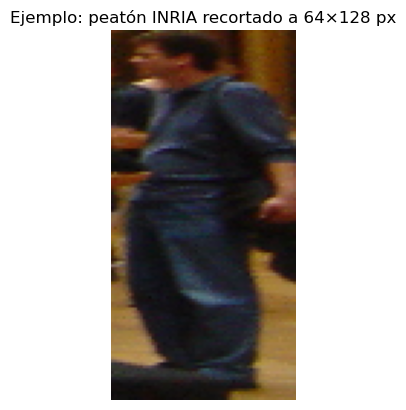

In [8]:
# Sin cambios respecto al original.
img_color = pedestrian[10]
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Ejemplo: peatón INRIA recortado a 64×128 px")
plt.axis('off')
plt.show()

# Para fines de demostración se calcula el HOG de la imagen

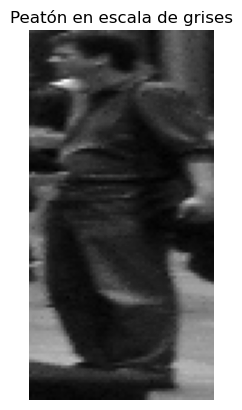

In [9]:
# Sin cambios respecto al original.
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap="gray")
plt.title("Peatón en escala de grises")
plt.axis('off')
plt.show()

In [10]:
# MODIFICACIÓN: parámetros HOG ajustados al estándar de Dalal & Triggs (2005):
#   - pixels_per_cell=(8,8)  en lugar de (16,16): celdas más finas para
#     capturar contornos de piernas, torso y cabeza en imágenes de 64×128.
#   - orientations=9         en lugar de 11: valor canónico del paper original.
#   - cells_per_block=(2,2)  sin cambio.
# Con imagen 64×128 y celdas 8×8:
#   bloques = (64/8-1) × (128/8-1) = 7×15 = 105 bloques
#   features = 105 × 2×2×9 = 3,780 dimensiones (vs 396 del original).
features, hog_img = hog(img_gray,
                        orientations=9,
                        pixels_per_cell=(8, 8),
                        cells_per_block=(2, 2),
                        transform_sqrt=False,
                        visualize=True,
                        feature_vector=True)

In [11]:
features.shape

(3780,)

In [12]:
hog_img.shape

(128, 64)

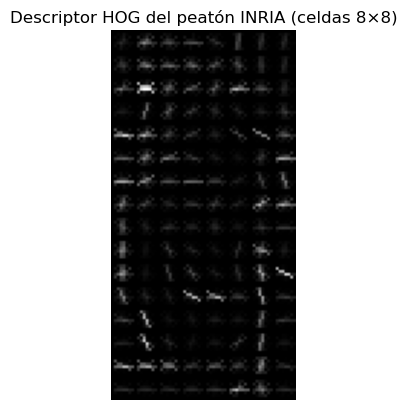

In [13]:
plt.imshow(hog_img, cmap='gray')
plt.title("Descriptor HOG del peatón INRIA (celdas 8×8)")
plt.axis('off')
plt.show()

# Se extraen las features del HOG para ambos tipos de datos

In [14]:
# MODIFICACIÓN: se itera sobre recortes en memoria en lugar de rutas de archivo.
# Parámetros HOG actualizados a estándar Dalal & Triggs.
pedestrian_hog_accum = []

for img_color in pedestrian:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    feat, _ = hog(img_gray,
                  orientations=9,
                  pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2),
                  transform_sqrt=False,
                  visualize=True,
                  feature_vector=True)
    pedestrian_hog_accum.append(feat)

In [15]:
# MODIFICACIÓN: nombre cambia de X_vehicle a X_pedestrian. Etiqueta 1 = peatón.
X_pedestrian = np.vstack(pedestrian_hog_accum).astype(np.float64)
y_pedestrian = np.ones(len(X_pedestrian))

In [16]:
X_pedestrian.shape

(1237, 3780)

In [17]:
y_pedestrian.shape

(1237,)

In [18]:
# MODIFICACIÓN: clase negativa son parches aleatorios de fondo (no imágenes
# pre-recortadas como en el original). Mismos parámetros HOG.
nopedestrian_hog_accum = []

for img_color in no_pedestrian:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    feat, _ = hog(img_gray,
                  orientations=9,
                  pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2),
                  transform_sqrt=False,
                  visualize=True,
                  feature_vector=True)
    nopedestrian_hog_accum.append(feat)

In [19]:
# MODIFICACIÓN: nombre cambia de X_novehicle a X_nopedestrian. Etiqueta 0 = fondo.
X_nopedestrian = np.vstack(nopedestrian_hog_accum).astype(np.float64)
y_nopedestrian = np.zeros(len(X_nopedestrian))

In [20]:
X_nopedestrian.shape

(1824, 3780)

In [21]:
y_nopedestrian.shape

(1824,)

# Se combinan ambos tipos de datos para alimentar el SVM

In [22]:
# Sin cambios respecto al original.
X = np.vstack((X_pedestrian, X_nopedestrian))
X.shape

(3061, 3780)

In [23]:
y = np.hstack((y_pedestrian, y_nopedestrian))
y.shape

(3061,)

# Se generan los datos de entrenamiento y de prueba

In [24]:
# Sin cambios respecto al original.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
X_train.shape

(2142, 3780)

In [26]:
X_test.shape

(919, 3780)

# Se importa el Clasificador y se entrena

In [27]:
# Sin cambios respecto al original.
from sklearn.svm import SVC

svc_model = SVC()
svc_model.fit(X_train, y_train)

SVC()

In [28]:
y_predict = svc_model.predict(X_test)

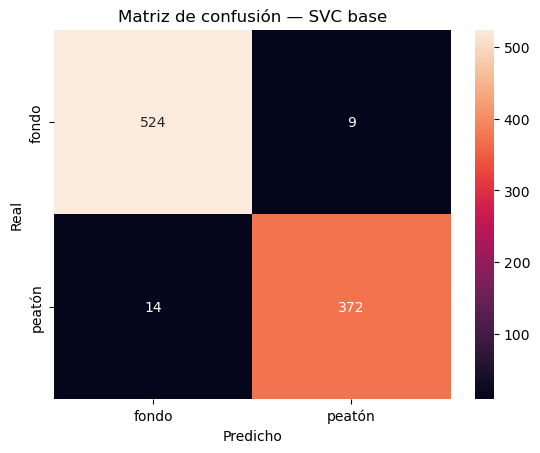

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_test, y_predict)
# MODIFICACIÓN: etiquetas actualizadas a fondo/peatón.
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["fondo", "peatón"],
            yticklabels=["fondo", "peatón"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — SVC base")
plt.show()

In [30]:
# MODIFICACIÓN: etiquetas actualizadas.
print(classification_report(y_test, y_predict,
                            target_names=["fondo", "peatón"]))

              precision    recall  f1-score   support

       fondo       0.97      0.98      0.98       533
      peatón       0.98      0.96      0.97       386

    accuracy                           0.97       919
   macro avg       0.98      0.97      0.97       919
weighted avg       0.97      0.97      0.97       919



# GridSearchCV

In [31]:
# MODIFICACIÓN: se incluye gamma='scale' en el grid (lección aprendida del
# notebook PnPLO: el valor adaptativo supera a valores fijos con este tipo de datos).
param_grid = {
    'C':      [0.1, 1, 10, 100, 1000],
    'gamma':  ['scale', 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

In [32]:
# Sin cambios respecto al original.
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=4)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.935 total time=   3.5s
[CV 2/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.930 total time=   3.5s
[CV 3/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.918 total time=   3.5s
[CV 4/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.921 total time=   3.4s
[CV 5/5] END ....C=0.1, gamma=scale, kernel=rbf;, score=0.916 total time=   3.4s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.601 total time=   4.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.604 total time=   4.3s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.603 total time=   4.2s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.603 total time=   4.2s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.603 total time=   4.3s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.930 total time=   3.3s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=4)

In [33]:
grid.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [34]:
grid.best_estimator_

SVC(C=1)

In [35]:
grid_predictions = grid.predict(X_test)

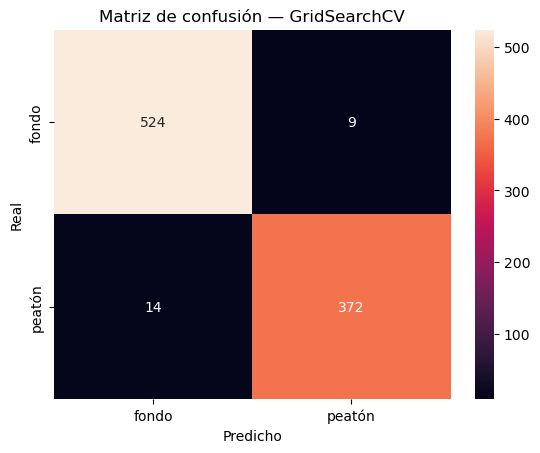

In [36]:
cm = confusion_matrix(y_test, grid_predictions)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["fondo", "peatón"],
            yticklabels=["fondo", "peatón"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión — GridSearchCV")
plt.show()

In [37]:
# MODIFICACIÓN: etiquetas actualizadas.
print(classification_report(y_test, grid_predictions,
                            target_names=["fondo", "peatón"]))

              precision    recall  f1-score   support

       fondo       0.97      0.98      0.98       533
      peatón       0.98      0.96      0.97       386

    accuracy                           0.97       919
   macro avg       0.98      0.97      0.97       919
weighted avg       0.97      0.97      0.97       919



# Exportación del modelo

In [38]:
import joblib

# Se exporta el mejor estimador obtenido por GridSearchCV
joblib.dump(grid.best_estimator_, "svm_inria_hog.joblib")
print("Modelo exportado como: svm_inria_hog.joblib")

# Para cargarlo en otro script:
# model = joblib.load("svm_inria_hog.joblib")

Modelo exportado como: svm_inria_hog.joblib
